This tutorial covers the workflow of a sequence classification project with PyTorch. We'll cover the basics of sequence classification using a simple, but effective, neural bag-of-words model, and how to use the datasets/torchtext libaries to simplify data loading/preprocessing.

Import Modules

In [2]:
import collections

import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchtext
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import tqdm

In [3]:
seed = 1234
np.random.seed(seed)
torch.manual_seed(seed)

Loading the Dataset

In [4]:
train_data, test_data = datasets.load_dataset('imdb', split=['train', 'test'])

In [5]:
train_data, test_data

(Dataset({
     features: ['text', 'label'],
     num_rows: 25000
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 25000
 }))

In [6]:
train_data.features

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

In [7]:
test_data.features

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

In [8]:
train_data[0]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

Tokenization

In [9]:
# tokenizer = torchtext.data.utils.get_tokenizer('basic_english')  # from torchtext.data.utils import get_tokenizer
tokenizer = get_tokenizer('basic_english')

In [10]:
tokenizer("Hello World! How are you doing today? i'm doing fantastic!")

['hello',
 'world',
 '!',
 'how',
 'are',
 'you',
 'doing',
 'today',
 '?',
 'i',
 "'",
 'm',
 'doing',
 'fantastic',
 '!']

In [11]:
def tokenize_example(example, tokenizer, maxlength):
    tokens = tokenizer(example['text'])[:maxlength]
    return {'tokens': tokens}

In [12]:
tokenize_example(train_data[0], tokenizer, maxlength=200)

{'tokens': ['i',
  'rented',
  'i',
  'am',
  'curious-yellow',
  'from',
  'my',
  'video',
  'store',
  'because',
  'of',
  'all',
  'the',
  'controversy',
  'that',
  'surrounded',
  'it',
  'when',
  'it',
  'was',
  'first',
  'released',
  'in',
  '1967',
  '.',
  'i',
  'also',
  'heard',
  'that',
  'at',
  'first',
  'it',
  'was',
  'seized',
  'by',
  'u',
  '.',
  's',
  '.',
  'customs',
  'if',
  'it',
  'ever',
  'tried',
  'to',
  'enter',
  'this',
  'country',
  ',',
  'therefore',
  'being',
  'a',
  'fan',
  'of',
  'films',
  'considered',
  'controversial',
  'i',
  'really',
  'had',
  'to',
  'see',
  'this',
  'for',
  'myself',
  '.',
  'the',
  'plot',
  'is',
  'centered',
  'around',
  'a',
  'young',
  'swedish',
  'drama',
  'student',
  'named',
  'lena',
  'who',
  'wants',
  'to',
  'learn',
  'everything',
  'she',
  'can',
  'about',
  'life',
  '.',
  'in',
  'particular',
  'she',
  'wants',
  'to',
  'focus',
  'her',
  'attentions',
  'to',
  '

In [13]:
maxlength = 256
train_data = train_data.map(tokenize_example, fn_kwargs={'tokenizer': tokenizer ,'maxlength': maxlength})
test_data = test_data.map(tokenize_example, fn_kwargs={'tokenizer': tokenizer ,'maxlength': maxlength})

In [14]:
train_data

Dataset({
    features: ['text', 'label', 'tokens'],
    num_rows: 25000
})

In [15]:
train_data.features

{'text': Value('string'),
 'label': ClassLabel(names=['neg', 'pos']),
 'tokens': List(Value('string'))}

In [16]:
train_data[0]['tokens'][0:25]

['i',
 'rented',
 'i',
 'am',
 'curious-yellow',
 'from',
 'my',
 'video',
 'store',
 'because',
 'of',
 'all',
 'the',
 'controversy',
 'that',
 'surrounded',
 'it',
 'when',
 'it',
 'was',
 'first',
 'released',
 'in',
 '1967',
 '.']

Creating Validation Data

In [17]:
valid_size = 0.25
train_valid_data = train_data.train_test_split(test_size=valid_size)
train_data = train_valid_data['train']
valid_data = train_valid_data['test']

In [18]:
train_data.shape, valid_data.shape, test_data.shape

((18750, 3), (6250, 3), (25000, 3))

Creating a Vocabulary

In [19]:
min_freq = 5
special_token = ['<unk>', '<pad>']

vocab = build_vocab_from_iterator(
    train_data['tokens'],
    min_freq=min_freq,
    specials=special_token
)

In [20]:
vocab.lookup_token(2)

'the'

In [21]:
len(vocab)

21635

In [22]:
vocab.get_itos()[:10]

['<unk>', '<pad>', 'the', '.', ',', 'a', 'and', 'of', 'to', "'"]

In [23]:
vocab['and']

6

In [24]:
unk_index = vocab['<unk>']
pad_index = vocab['<pad>']

In [25]:
'some_token' in vocab

False

In [26]:
'man' in vocab

True

In [27]:
vocab.set_default_index(unk_index)

In [28]:
vocab['some_token']

0

In [31]:
vocab.lookup_indices(['hello', 'world', 'some_token', '<pad>'])

[5516, 184, 0, 1]

Numericalizing Data

In [32]:
def numerical_example(example, vocab):
    ids = vocab.lookup_indices(example['tokens'])
    return {'ids': ids}

In [33]:
train_data = train_data.map(numerical_example, fn_kwargs={'vocab': vocab})
test_data = test_data.map(numerical_example, fn_kwargs={'vocab': vocab})
valid_data = valid_data.map(numerical_example, fn_kwargs={'vocab': vocab})

Map:   0%|          | 0/18750 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

In [34]:
train_data[0]['tokens'][0:10]

['look', ',', 'this', 'is', 'quite', 'possibly', 'one', 'of', 'the', 'best']

In [35]:
vocab.lookup_indices(train_data[0]['tokens'][0:10])

[180, 4, 14, 10, 191, 841, 34, 7, 2, 121]

In [36]:
train_data[0]['ids'][0: 10]

[180, 4, 14, 10, 191, 841, 34, 7, 2, 121]

In [37]:
train_data = train_data.with_format(type='torch', columns=['ids', 'label'])
valid_data = valid_data.with_format(type='torch', columns=['ids', 'label'])
test_data = test_data.with_format(type='torch', columns=['ids', 'label'])

In [39]:
train_data[0]['label']

tensor(1)

In [47]:
vocab.lookup_tokens(train_data[0]["ids"][:10].tolist())

['look', ',', 'this', 'is', 'quite', 'possibly', 'one', 'of', 'the', 'best']

Creating Data Loaders

In [131]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_ids = [i['ids'] for i in batch]
        batch_ids = nn.utils.rnn.pad_sequence(batch_ids,padding_value=pad_index, batch_first=True)
        batch_labels = [i['label'] for i in batch]
        batch_labels = torch.stack(batch_labels)
        return {'ids': batch_ids, 'label': batch_labels}

    return collate_fn

In [132]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(dataset=dataset,
                                              batch_size=batch_size,
                                              collate_fn=collate_fn,
                                              shuffle=shuffle)
    return data_loader

In [133]:
batch_size = 512

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

Building the Model

In [54]:
class NBoW(nn.Module):
    def __init__(self, vocab_size, embedding_dim, output_dim, pad_index):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_index)
        self.fc = nn.Linear(embedding_dim, output_dim)

    def forward(self, ids):
        embedded = self.embedding(ids)
        pooled = embedded.mean(dim=1)
        prediction = self.fc(pooled)
        return prediction

In [55]:
vocab_size = len(vocab)
output_dim = len(train_data.unique('label'))
embedding_dim = 300

model = NBoW(vocab_size, embedding_dim, output_dim, pad_index)

In [64]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 6,491,102 trainable parameters


Initial Embedding Parameters

In [70]:
vectors = torchtext.vocab.GloVe()

.vector_cache\glove.840B.300d.zip: 2.18GB [07:51, 4.62MB/s]                                
100%|█████████▉| 2196016/2196017 [02:50<00:00, 12894.07it/s]


In [73]:
hello_vector = vectors.get_vecs_by_tokens('hello')

In [75]:
hello_vector.shape

torch.Size([300])

In [86]:
vectors.get_vecs_by_tokens('<unk>'), vectors.get_vecs_by_tokens('<pad>'), vectors.get_vecs_by_tokens('<dsfsdvx>')

(tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [76]:
pretrained_embedding = vectors.get_vecs_by_tokens(vocab.get_itos())

In [77]:
pretrained_embedding.shape

torch.Size([21635, 300])

In [81]:
model.embedding.weight

Parameter containing:
tensor([[-0.1117, -0.4966,  0.1631,  ..., -0.5592, -0.4480, -0.6476],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.7882, -1.6625, -0.7064,  ..., -1.5841, -0.3711, -1.2338],
        ...,
        [-0.1833,  0.2245, -0.3846,  ..., -0.8093, -1.5803,  2.2097],
        [ 0.8763, -0.4503, -0.3297,  ...,  1.0524, -0.3182, -0.0381],
        [-0.7596,  0.6286,  0.0057,  ..., -0.8484, -0.1224,  1.3181]],
       requires_grad=True)

In [82]:
model.embedding.weight.shape

torch.Size([21635, 300])

In [87]:
pretrained_embedding

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.2720, -0.0620, -0.1884,  ...,  0.1302, -0.1832,  0.1323],
        ...,
        [ 0.1662,  0.2845,  0.4958,  ..., -0.5733, -0.4675, -0.0965],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.2701,  0.6335,  0.2016,  ..., -0.4568,  0.5783, -0.5545]])

In [88]:
model.embedding.weight.data = pretrained_embedding

In [89]:
model.embedding.weight

Parameter containing:
tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.2720, -0.0620, -0.1884,  ...,  0.1302, -0.1832,  0.1323],
        ...,
        [ 0.1662,  0.2845,  0.4958,  ..., -0.5733, -0.4675, -0.0965],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.2701,  0.6335,  0.2016,  ..., -0.4568,  0.5783, -0.5545]],
       requires_grad=True)

In [90]:
optimizer = optim.Adam(model.parameters())

In [91]:
criterion = nn.CrossEntropyLoss()

In [92]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [93]:
device

device(type='cpu')

In [95]:
model = model.to(device)
criterion = criterion.to(device)

In [139]:
def train(data_loader, model, criterion, optimizer, device):
    model.train()
    epoch_loss = []
    epoch_accs = []
    for batch in tqdm.tqdm(data_loader, desc='training...'):
        # print(batch.keys())
        ids = batch['ids'].to(device)
        label = batch['label'].to(device)
        prediction = model(ids)
        loss = criterion(prediction, label)
        accuracy = get_accuracy(prediction, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
        epoch_accs.append(accuracy.item())
    return np.mean(epoch_loss), np.mean(epoch_accs)

In [135]:
def evaluate(data_loader, model, criterion, device):
    model.eval()
    epoch_loss = []
    epoch_accs = []
    with torch.no_grad():
        for batch in tqdm.tqdm(data_loader, desc='evaluating...'):
            ids = batch['ids'].to(device)
            label = batch['label'].to(device)
            prediction = model(ids)
            loss = criterion(prediction, label)
            accuracy = get_accuracy(prediction, label)
            epoch_loss.append(loss.item())
            epoch_accs.append(accuracy.item())
    return np.mean(epoch_loss), np.mean(epoch_accs)

In [136]:
def get_accuracy(prediction, label):
    batch_size, _ = prediction.shape
    prediction_classes = prediction.argmax(dim=-1)
    correct_predictions = prediction_classes.eq(label).sum()
    accuracy = correct_predictions / batch_size
    return accuracy

In [140]:
n_epochs = 10
best_valid_loss = float('inf')

metrics = collections.defaultdict(list)

for epoch in range(n_epochs):
    train_loss, train_acc = train(train_data_loader, model, criterion, optimizer, device)
    valid_loss, valid_acc = evaluate(valid_data_loader, model, criterion, device)
    metrics['train_loss'].append(train_loss)
    metrics['train_acc'].append(train_acc)
    metrics['valid_loss'].append(valid_loss)
    metrics['valid_acc'].append(valid_acc)
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), './best_model/nbow.pt')
    print(f'epoch: {epoch+1}')
    print(f'train_loss: {train_loss:.3f}, train_acc: {train_acc:.3f}')
    print(f'valid_loss: {valid_loss:.3f}, valid_acc: {valid_acc:.3f}')

evaluating...: 100%|██████████| 13/13 [00:00<00:00, 28.45it/s]


epoch: 1
train_loss: 0.550, train_acc: 0.790
valid_loss: 0.523, valid_acc: 0.799


evaluating...: 100%|██████████| 13/13 [00:00<00:00, 28.13it/s]


epoch: 2
train_loss: 0.479, train_acc: 0.830
valid_loss: 0.463, valid_acc: 0.830


evaluating...: 100%|██████████| 13/13 [00:00<00:00, 28.18it/s]


...

epoch: 8
train_loss: 0.251, train_acc: 0.917
valid_loss: 0.317, valid_acc: 0.877


evaluating...: 100%|██████████| 13/13 [00:00<00:00, 29.62it/s]


epoch: 9
train_loss: 0.233, train_acc: 0.923
valid_loss: 0.306, valid_acc: 0.879


evaluating...: 100%|██████████| 13/13 [00:00<00:00, 25.66it/s]

epoch: 10
train_loss: 0.216, train_acc: 0.930
valid_loss: 0.300, valid_acc: 0.880


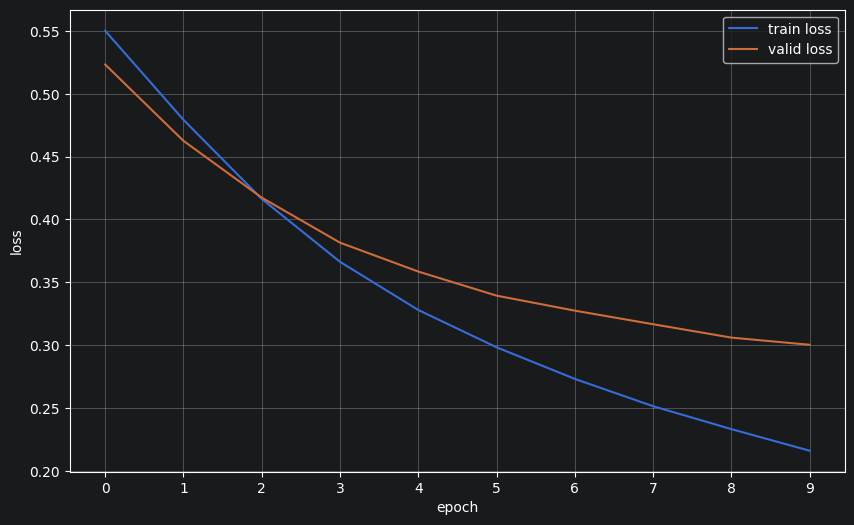

In [141]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1,1,1)
ax.plot(metrics['train_loss'], label='train loss')
ax.plot(metrics['valid_loss'], label='valid loss')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

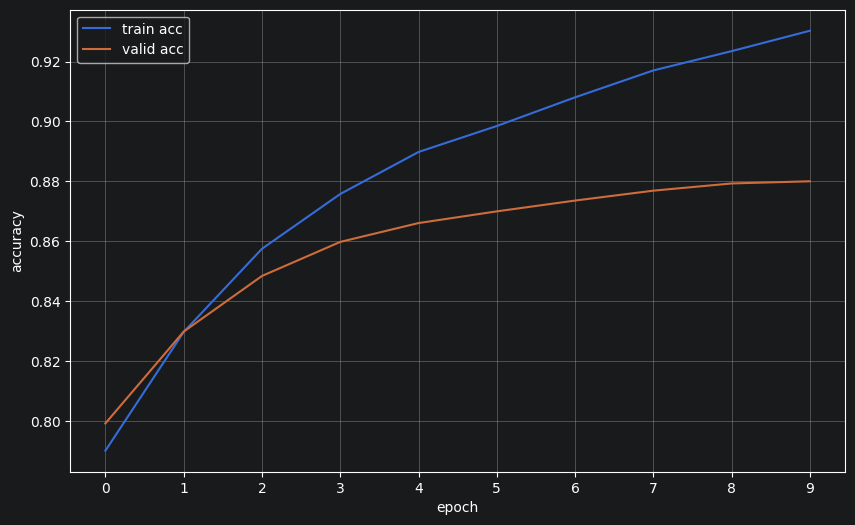

In [143]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1,1,1)
ax.plot(metrics['train_acc'], label='train acc')
ax.plot(metrics['valid_acc'], label='valid acc')
ax.set_xlabel('epoch')
ax.set_ylabel('accuracy')
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

In [145]:
model.load_state_dict(torch.load('./best_model/nbow.pt'))
test_loss, test_acc = evaluate(test_data_loader, model, criterion, device)

evaluating...: 100%|██████████| 49/49 [00:02<00:00, 24.08it/s]


In [146]:
print(f'test loss: {test_loss:.3f}, test acc: {test_acc:.3f}')

test loss: 0.338, test acc: 0.861


随机预测，检测模型

In [210]:
def predict_sentiment(text, model, tokenizer, vocab, device):
    tokens = tokenizer(text)
    ids = vocab.lookup_indices(tokens)
    tensor = torch.LongTensor(ids).unsqueeze(dim=0).to(device)
    with torch.no_grad():
        predictions = model(tensor).squeeze(dim=0)
    probability = torch.softmax(predictions, dim=-1)
    predicted_class = probability.argmax(dim=-1).item()
    predicted_probability = probability[predicted_class].item()
    return predicted_class, predicted_probability

In [229]:
text = 'though it is good, i it'

In [230]:
predict_sentiment(text, model, tokenizer, vocab, device)

(1, 1.0)